# Backbones — experiments

The two algorithms (variants) are in `backbone.py`, the independent checking in `verify.py` and the helper for metrics in `bench.py`. This notebook runs them and produces the tables and figures used in the report.

Note: Everything in `verify.py` creates its own solver instances, so no call made while verifying is ever counted in the measured results.

In [1]:
%load_ext autoreload
%autoreload 2

import platform
import sys

import pysat

print(sys.version)
print(platform.platform())
print(platform.processor())
print("python-sat", pysat.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Windows-10-10.0.26200-SP0
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
python-sat 1.9.dev7


## 1. Correctness on small formulas

Both algorithms must return the same set, and it must be the one written down by inspection.

In [2]:
import pandas as pd

from backbone import ALGORITHMS, Cnf, backbones, read_dimacs

def cnf(n, cs):
    return Cnf(n_vars=n, clauses=[list(c) for c in cs])

cases = [
    ("unit clause",           cnf(2, [[1], [1, 2]]),        {1}),
    ("two units",             cnf(3, [[1], [-2], [1, 3]]),  {1, -2}),
    ("forced by propagation", cnf(2, [[1], [-1, 2]]),       {1, 2}),
    ("free variable",         cnf(2, [[1, 2], [-1, -2]]),   set()),
    ("implied literal",       cnf(3, [[1, 2], [-1, 2]]),    {2}),
    ("no clauses",            cnf(2, []),                   set()),
    ("all fixed",             cnf(2, [[1], [2]]),           {1, 2}),
    ("unsatisfiable",         cnf(2, [[1], [-1]]),          {1, -1, 2, -2}),
]

rows = []
for name, f, want in cases:
    got = {a: set(backbones(f, a).backbone) for a in ALGORITHMS}
    rows.append({"case": name,
                 "expected": sorted(want),
                 "propagate": sorted(got["propagate"]),
                 "complement": sorted(got["complement"]),
                 "ok": got["propagate"] == got["complement"] == want})

df_small = pd.DataFrame(rows)
print("all correct:", bool(df_small.ok.all()))
df_small

all correct: True


,case,expected,propagate,complement,ok
0,unit clause,[1],[1],[1],True
1,two units,"[-2, 1]","[-2, 1]","[-2, 1]",True
2,forced by propagation,"[1, 2]","[1, 2]","[1, 2]",True
3,free variable,[],[],[],True
4,implied literal,[2],[2],[2],True
5,no clauses,[],[],[],True
6,all fixed,"[1, 2]","[1, 2]","[1, 2]",True
7,unsatisfiable,"[-2, -1, 1, 2]","[-2, -1, 1, 2]","[-2, -1, 1, 2]",True


## 2. Exhaustive verification on small instances

Every one of the $2n$ literals is tested separately with a fresh solver, so the reported set is confirmed to be neither too large nor too small. This costs $2n$ extra calls and is only affordable here, which is why it is not part of the measured runs.

In [3]:
import glob
import os

from bench import BENCH_DIR
from verify import check

paths = []
for fam in ["uf20-91", "flat30-60"]:
    paths += sorted(glob.glob(os.path.join(BENCH_DIR, fam, "*.cnf")))[:3]

rows = []
for p in paths:
    f = read_dimacs(p)
    for algo in ALGORITHMS:
        r = backbones(f, algo)
        ok, problems = check(f, r.backbone)
        rows.append({"instance": os.path.basename(p), "algorithm": algo,
                     "vars": f.n_vars, "literals checked": 2 * f.n_vars,
                     "backbones": r.size, "verified": ok,
                     "problems": "; ".join(problems[:3])})

df_verify = pd.DataFrame(rows)
print("all verified:", bool(df_verify.verified.all()))
df_verify

all verified: True


,instance,algorithm,vars,literals checked,backbones,verified,problems
0,uf20-01.cnf,propagate,20,40,8,True,
1,uf20-01.cnf,complement,20,40,8,True,
2,uf20-010.cnf,propagate,20,40,8,True,
3,uf20-010.cnf,complement,20,40,8,True,
4,uf20-0100.cnf,propagate,20,40,11,True,
5,uf20-0100.cnf,complement,20,40,11,True,
6,flat30-1.cnf,propagate,90,180,0,True,
7,flat30-1.cnf,complement,90,180,0,True,
8,flat30-10.cnf,propagate,90,180,0,True,
9,flat30-10.cnf,complement,90,180,0,True,


## 3. Ground truth from the CBS family

The Controlled Backbone Size instances fix the number of backbone variables and state it in the family name, so `b30` must yield exactly 30 backbones. This is external ground truth that costs no solving and it covers instances far too large for the exhaustive check above.

In [4]:
from verify import cbs_expected_size

rows = []
for fam in sorted(d for d in os.listdir(BENCH_DIR) if d.startswith("CBS")):
    want = cbs_expected_size(fam)
    for p in sorted(glob.glob(os.path.join(BENCH_DIR, fam, "*.cnf"))):
        f = read_dimacs(p)
        for algo in ALGORITHMS:
            r = backbones(f, algo)
            rows.append({"family": fam, "instance": os.path.basename(p),
                         "algorithm": algo, "expected": want,
                         "found": r.size, "match": r.size == want})

df_cbs = pd.DataFrame(rows)
print(f"{len(df_cbs)} runs, matching the stated backbone size: {int(df_cbs.match.sum())}")
df_cbs.groupby(["expected", "algorithm"]).agg(runs=("match", "count"),
                                              matching=("match", "sum"))

150 runs, matching the stated backbone size: 150


runs  matching
expected algorithm                 
10       complement    15        15
         propagate     15        15
30       complement    15        15
         propagate     15        15
50       complement    15        15
         propagate     15        15
70       complement    15        15
         propagate     15        15
90       complement    15        15
         propagate     15        15

## 4. Benchmarks

All instances come from the families of the SATLIB collection that are described as containing only satisfiable formulas (kept in a benchmarks_allSAT folder). 

In [5]:
from bench import families, instances

rows = []
for fam in families():
    for p in instances(fam):
        f = read_dimacs(p)
        rows.append({"family": fam, "instance": os.path.basename(p),
                     "vars": f.n_vars, "clauses": f.n_clauses})

df_bench = pd.DataFrame(rows)
print(f"{df_bench.family.nunique()} families, {len(df_bench)} instances, "
      f"{df_bench.vars.min()} to {df_bench.vars.max()} variables")
df_bench.groupby("family").agg(instances=("instance", "count"),
                               vars=("vars", "max"), clauses=("clauses", "max"))

27 families, 131 instances, 20 to 6325 variables


,instances,vars,clauses
family,,,
BMS_k3_n100_m429,5,100,308
CBS_k3_n100_m403_b10,5,100,403
CBS_k3_n100_m403_b30,5,100,403
CBS_k3_n100_m403_b50,5,100,403
CBS_k3_n100_m403_b70,5,100,403
CBS_k3_n100_m403_b90,5,100,403
CBS_k3_n100_m429_b10,5,100,429
CBS_k3_n100_m429_b30,5,100,429
CBS_k3_n100_m429_b50,5,100,429


## 5. The sweep

Both algorithms on every instance. The naive baseline of one call per literal, $2n$ in total, is recorded alongside for reference and is not run, since its cost is fixed by the number of variables.

In [6]:
import time

from bench import sweep, to_records

t0 = time.perf_counter()
rows = sweep(verbose=False)
elapsed = time.perf_counter() - t0

df = pd.DataFrame(to_records(rows))
df.to_csv("results.csv", index=False)

print(f"{len(df)} runs in {elapsed:.1f}s, errors: {int(df.error.notna().sum())}")
df.head(10)

262 runs in 102.8s, errors: 0


,family,instance,n_vars,n_clauses,algorithm,solver,order,backbone_size,backbone_hash,expected_size,calls,free,rounds,load_time,solve_time,error,naive_calls,saving,matches_expected
0,BMS_k3_n100_m429,BMS_k3_n100_m429_0.cnf,100,286,propagate,cadical153,index,51,7ae189435c5fc3be,NaN,49,13,48,0.001658,0.114101,None,200,0.755,None
1,BMS_k3_n100_m429,BMS_k3_n100_m429_0.cnf,100,286,complement,cadical153,index,51,7ae189435c5fc3be,NaN,35,0,34,0.002837,0.048061,None,200,0.825,None
2,BMS_k3_n100_m429,BMS_k3_n100_m429_1.cnf,100,272,propagate,cadical153,index,53,0dd7e2795fd12be8,NaN,45,22,44,0.001610,0.017448,None,200,0.775,None
3,BMS_k3_n100_m429,BMS_k3_n100_m429_1.cnf,100,272,complement,cadical153,index,53,0dd7e2795fd12be8,NaN,38,0,37,0.001545,0.016940,None,200,0.810,None
4,BMS_k3_n100_m429,BMS_k3_n100_m429_10.cnf,100,287,propagate,cadical153,index,21,8fe429c94940f803,NaN,38,1,37,0.001588,0.058722,None,200,0.810,None
5,BMS_k3_n100_m429,BMS_k3_n100_m429_10.cnf,100,287,complement,cadical153,index,21,8fe429c94940f803,NaN,43,0,42,0.001629,0.058312,None,200,0.785,None
6,BMS_k3_n100_m429,BMS_k3_n100_m429_100.cnf,100,308,propagate,cadical153,index,17,fc3a32946dd5ca5d,NaN,25,2,24,0.001687,0.110828,None,200,0.875,None
7,BMS_k3_n100_m429,BMS_k3_n100_m429_100.cnf,100,308,complement,cadical153,index,17,fc3a32946dd5ca5d,NaN,35,0,34,0.001648,0.112958,None,200,0.825,None
8,BMS_k3_n100_m429,BMS_k3_n100_m429_101.cnf,100,306,propagate,cadical153,index,3,b166ceccfef9eeab,NaN,16,0,15,0.002085,0.077311,None,200,0.920,None
9,BMS_k3_n100_m429,BMS_k3_n100_m429_101.cnf,100,306,complement,cadical153,index,3,b166ceccfef9eeab,NaN,58,0,57,0.002839,0.064331,None,200,0.710,None


## 6. The two algorithms must be equivalent

They compute the same set by different means, so on every instance the reported backbone must be identical.

In [7]:
wide = df.pivot_table(index=["family", "instance"], columns="algorithm",
                      values="backbone_hash", aggfunc="first")
disagree = wide[wide.propagate != wide.complement]

print(f"instances: {len(wide)}, disagreements: {len(disagree)}")
print("compared on a fingerprint of the literals, so this is set equality "
      "and not only equal counts")
disagree

instances: 131, disagreements: 0
compared on a fingerprint of the literals, so this is set equality and not only equal counts


,algorithm,complement,propagate
family,instance,,


## 7. Solver calls and runtime

The number of calls to SAT solver is the quantity the task asks to minimise. Time is reported as well.

In [8]:
summary = df.groupby("algorithm").agg(
    runs=("calls", "count"),
    calls_total=("calls", "sum"),
    calls_median=("calls", "median"),
    calls_max=("calls", "max"),
    free_total=("free", "sum"),
    load_s=("load_time", "sum"),
    solve_s=("solve_time", "sum"),
).round(3)
summary["naive_total"] = int(df.groupby("algorithm").naive_calls.sum().iloc[0])
summary["vs naive"] = (summary.naive_total / summary.calls_total).round(1)
summary

,runs,calls_total,calls_median,calls_max,free_total,load_s,solve_s,naive_total,vs naive
algorithm,,,,,,,,,
complement,131,6367,25.0,2395,0,0.473,30.083,64410,10.1
propagate,131,7083,32.0,1354,13477,0.485,63.138,64410,9.1


## 8. Calls against backbone size

The experiment the CBS family exists for. The clause count is fixed within each column, so the only thing varying is how many variables are forced.

In [9]:
cbs = df[df.family.str.startswith("CBS")].copy()
cbs["m"] = cbs.family.str.extract(r"_m(\d+)_").astype(int)

print("mean calls, all three clause counts")
t = cbs.pivot_table(index="expected_size", columns=["m", "algorithm"],
                    values="calls", aggfunc="mean").round(1)
print(t.to_string())
print()
print("averaged over clause counts")
avg = cbs.pivot_table(index="expected_size", columns="algorithm",
                      values="calls", aggfunc="mean").round(1)
avg["naive"] = 200
avg

mean calls, all three clause counts
m                    403                  429                  449          
algorithm     complement propagate complement propagate complement propagate
expected_size                                                               
10.0                45.4      25.8       56.8      27.4       53.4      28.8
30.0                35.2      41.4       40.0      39.8       31.6      38.0
50.0                27.8      42.0       24.0      42.2       21.8      45.6
70.0                23.0      39.6       20.2      39.6       22.6      36.8
90.0                11.8      24.2       11.6      23.6       10.0      27.4

averaged over clause counts


algorithm,complement,propagate,naive
expected_size,,,
10.0,51.9,27.3,200
30.0,35.6,39.7,200
50.0,24.5,43.3,200
70.0,21.9,38.7,200
90.0,11.1,25.1,200


## 9. Per family

Mean calls per instance, next to the naive baseline and the size of the backbone actually found.

In [10]:
per = df.pivot_table(index="family", columns="algorithm", values="calls",
                     aggfunc="mean").round(1)
per["naive"] = df.groupby("family").naive_calls.mean().round(0).astype(int)
per["backbone"] = df.groupby("family").backbone_size.mean().round(1)
per["vars"] = df.groupby("family").n_vars.max()
per["free"] = df[df.algorithm == "propagate"].groupby("family").free.mean().round(1)
per.sort_values("vars")

algorithm,complement,propagate,naive,backbone,vars,free
family,,,,,,
uf20-91,4.8,8.4,40,12.8,20,7.0
uf50-218,8.4,18.0,100,38.8,50,25.8
flat30-60,24.0,12.6,180,0.0,90,0.0
BMS_k3_n100_m429,41.8,34.6,200,29.0,100,7.6
CBS_k3_n100_m403_b70,23.0,39.6,200,70.0,100,41.0
CBS_k3_n100_m403_b10,45.4,25.8,200,10.0,100,0.2
CBS_k3_n100_m403_b30,35.2,41.4,200,30.0,100,4.6
CBS_k3_n100_m403_b50,27.8,42.0,200,50.0,100,19.0
CBS_k3_n100_m429_b50,24.0,42.2,200,50.0,100,17.8


## 10. Backbones obtained without a solver call

Unit propagation from the unit clauses, and from each backbone as it is committed, derives further backbones for free. Only the `propagate` algorithm exploits this, since `complement` confirms its candidates in bulk instead.

In [11]:
pr = df[(df.algorithm == "propagate") & (df.backbone_size > 0)].copy()
pr["share"] = (pr.free / pr.backbone_size).round(3)

free = pr.groupby("family").agg(backbone=("backbone_size", "mean"),
                                free=("free", "mean"),
                                share=("share", "mean")).round(2)
print(f"backbones found by propagation in total: {int(df.free.sum())}")
free[free.free > 0].sort_values("free", ascending=False)

backbones found by propagation in total: 13477


,backbone,free,share
family,,,
blocksworld,1590.71,1517.0,0.93
logistics,559.25,141.5,0.17
CBS_k3_n100_m429_b90,90.00,72.2,0.80
CBS_k3_n100_m403_b90,90.00,71.2,0.79
CBS_k3_n100_m449_b90,90.00,68.2,0.76
CBS_k3_n100_m449_b70,70.00,42.2,0.60
CBS_k3_n100_m403_b70,70.00,41.0,0.59
CBS_k3_n100_m429_b70,70.00,39.8,0.57
uf50-218,38.80,25.8,0.62


## 11. Figures

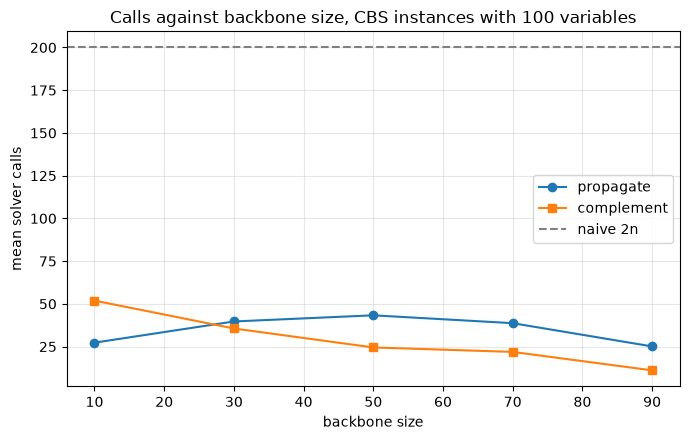

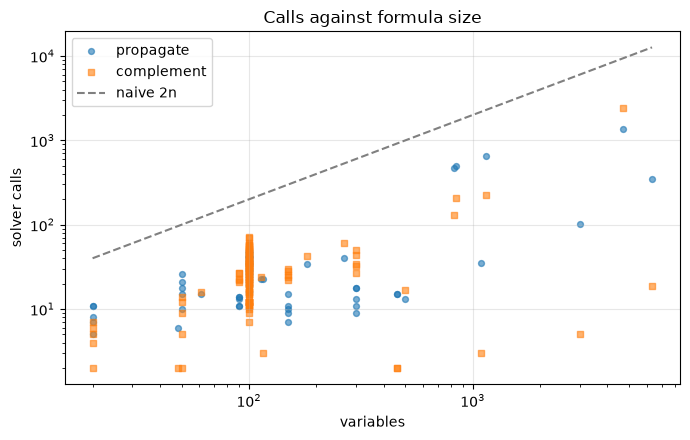

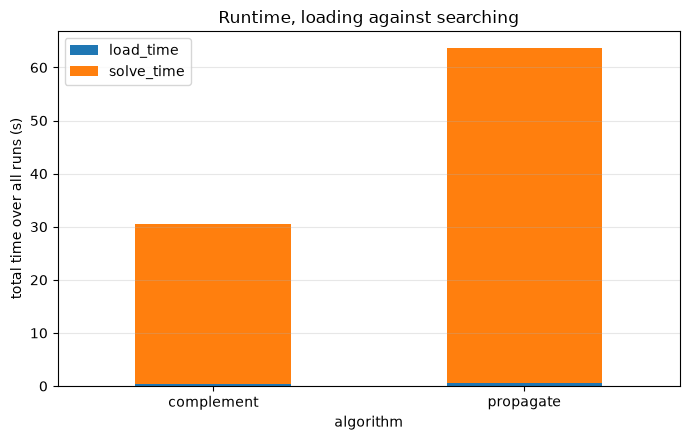

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt

figdir = Path("../report/figures")
figdir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
for algo, marker in [("propagate", "o"), ("complement", "s")]:
    sub = avg[algo]
    ax.plot(sub.index, sub.values, marker=marker, label=algo)
ax.axhline(200, linestyle="--", color="gray", label="naive 2n")
ax.set_xlabel("backbone size")
ax.set_ylabel("mean solver calls")
ax.set_title("Calls against backbone size, CBS instances with 100 variables")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "calls_vs_backbone.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for algo, marker in [("propagate", "o"), ("complement", "s")]:
    sub = df[df.algorithm == algo]
    ax.scatter(sub.n_vars, sub.calls, s=18, marker=marker, alpha=0.6, label=algo)
lim = df.n_vars.sort_values()
ax.plot(lim, 2 * lim, linestyle="--", color="gray", label="naive 2n")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("variables")
ax.set_ylabel("solver calls")
ax.set_title("Calls against formula size")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "calls_vs_size.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
t = df.groupby("algorithm")[["load_time", "solve_time"]].sum()
t.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("total time over all runs (s)")
ax.set_title("Runtime, loading against searching")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(figdir / "runtime.pdf")
plt.show()

## 12. Full verification

Everything above compares the two algorithms against each other, against the sizes stated by the CBS family, and against an exhaustive check on a handful of small instances. None of that confirms, for the whole benchmark set, that the literals reported are the right ones rather than merely the right number of them.

This section recomputes the backbone of every instance from scratch, testing each of the $2n$ literals separately with its own assumption, and compares the resulting set literal by literal with what each algorithm reported.

**The calls made here are not part of any measurement above.** They are made by `verify.py`, which builds its own solver, and they are reported separately below so that the cost of checking is visible without contaminating the cost of solving.

In [13]:
from verify import true_backbone

check_rows = []
t0 = time.perf_counter()

for fam in families():
    for path in instances(fam):
        f = read_dimacs(path)
        truth, check_calls = true_backbone(f)
        truth_set = set(truth)

        for algo in ALGORITHMS:
            got = set(backbones(f, algo).backbone)
            check_rows.append({
                "family": fam,
                "instance": os.path.basename(path),
                "vars": f.n_vars,
                "algorithm": algo,
                "true_size": len(truth_set),
                "reported_size": len(got),
                "missing": len(truth_set - got),
                "extra": len(got - truth_set),
                "identical": got == truth_set,
                "check_calls": check_calls,
            })

check_elapsed = time.perf_counter() - t0
df_check = pd.DataFrame(check_rows)
df_check.to_csv("verification.csv", index=False)

print(f"{len(df_check)} comparisons over {df_check.instance.nunique()} instances "
      f"in {check_elapsed:.1f}s")
print(f"identical literal sets: {int(df_check.identical.sum())} of {len(df_check)}")
print(f"instances with a missing literal: {int((df_check.missing > 0).sum())}")
print(f"instances with a spurious literal: {int((df_check.extra > 0).sum())}")
print()
print(f"calls made while checking: {int(df_check.groupby('instance').check_calls.first().sum()):,}")
print("these are not included in any table above")

df_check[~df_check.identical]

262 comparisons over 131 instances in 192.3s
identical literal sets: 262 of 262
instances with a missing literal: 0
instances with a spurious literal: 0

calls made while checking: 64,541
these are not included in any table above


,family,instance,vars,algorithm,true_size,reported_size,missing,extra,identical,check_calls


In [14]:
per_family = df_check.groupby("family").agg(
    instances=("instance", "nunique"),
    vars=("vars", "max"),
    backbone=("true_size", "mean"),
    identical=("identical", "all"),
    check_calls=("check_calls", "max"),
).round(1)

print("cost of checking against cost of solving")
solving = df.groupby("algorithm").calls.sum()
checking = df_check.groupby("instance").check_calls.first().sum()
print(f"  propagate   {int(solving['propagate']):>7,} calls")
print(f"  complement  {int(solving['complement']):>7,} calls")
print(f"  verifying   {int(checking):>7,} calls   (separate, not counted above)")
print()
per_family

cost of checking against cost of solving
  propagate     7,083 calls
  complement    6,367 calls
  verifying    64,541 calls   (separate, not counted above)



,instances,vars,backbone,identical,check_calls
family,,,,,
BMS_k3_n100_m429,5,100,29.0,True,201
CBS_k3_n100_m403_b10,5,100,10.0,True,201
CBS_k3_n100_m403_b30,5,100,30.0,True,201
CBS_k3_n100_m403_b50,5,100,50.0,True,201
CBS_k3_n100_m403_b70,5,100,70.0,True,201
CBS_k3_n100_m403_b90,5,100,90.0,True,201
CBS_k3_n100_m429_b10,5,100,10.0,True,201
CBS_k3_n100_m429_b30,5,100,30.0,True,201
CBS_k3_n100_m429_b50,5,100,50.0,True,201
